Neste notebook farei um classificador de digitos manuscritos usando uma rede neural convolucional

Importação de bibliotecas:

In [1]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms

Seta o seed para gerar números aleatórios

In [2]:
torch.manual_seed(123)

Cria um transformador que converte imagens em tensores PyTorch

Posteriormente ele será usado para converter o dataset em tensores

Além disso, ele normaliza as imagens dividindo cada pixel da imagem por 255

In [3]:
transform = transforms.ToTensor()

Baixa e carrega o conjunto de treinamento e teste do MNIST passando o transformador criado acima para que ele atue sobre o dataset.

In [4]:
train = datasets.MNIST(root = '.', train = True, download = True, transform = transform)
test = datasets.MNIST(root = '.', train = False, download = True, transform = transform)

train, test

(Dataset MNIST
     Number of datapoints: 60000
     Root location: .
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: .
     Split: Test
     StandardTransform
 Transform: ToTensor())

Primeira imagem do dataset de treinamento:

In [5]:
train.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

Shape do dataset:

In [6]:
train.data.shape

torch.Size([60000, 28, 28])

Parte do dataset de treino com os outputs desejados:

In [7]:
train.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

Divide os datasets de treino e teste em batches de 128 criando iteraveis para os datasets, e faz a normalização dos dados através do transformador que foi aplicado anteriormente nos datasets

In [8]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(train, batch_size = batch_size, shuffle = True)
test_loader = torch.utils.data.DataLoader(test, batch_size = batch_size, shuffle = False)

Converte o iterável train_loader em um iterador (Objeto que contém o método __next__() para buscar o próximo elemento), pega o próximo elemento do iterável (o primeiro elemento), converte o shape dela de (1, 28, 28) para (28, 28), e plota a imagem com matplotlib.

OBS: o 1 indica quantos canais de cores tem a imagem

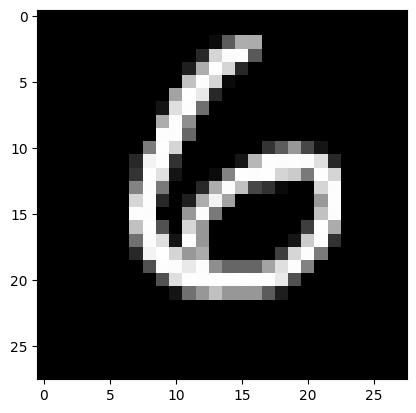

In [9]:
img = next(iter(train_loader))[0][0].view(28, 28)
plt.imshow(img, cmap = 'gray')

Definição do modelo:

In [10]:
class Classificador(nn.Module):
    def __init__(self):
        super().__init__()

        #Parte convolucional
        # in_channels = 1 pois a imagem tem apenas um canal de cor (cinza)
        # out_channels = 32 para a aplicação de 32 kernels diferentes nas imagens do dataset
        # a primeira camada convolucional produz 32 feature maps aplicando 32 kernels
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3))

        # A segunda camada convolucional recebe os 32 feature maps gerados pela camada anterior,
        # e gera 32 feature maps novos aplicando 32 kernels a cada entrada de 32 canais
        # 32 canais significa que o dado é composto de 32 camadas de informacoes, ou seja,
        # cada saida de conv2 é a aplicacao de um dos 32 kernels a um tensor de 32 camadas
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3))

        self.activation = nn.ReLU()

        # Aplica normalizacao de ativação nos 32 feature maps recebidos da camada anterior
        # Calcula a media e variencia dos 32 feature maps, e usa isso para normalizar a ativação, e atualiza a media total e variacao total
        self.bnorm = nn.BatchNorm2d(num_features=32)

        # Aplica uma camada de pooling (Max pooling) na saida da camada anterior
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))

        # Aplica flatten a saida da camada anterior
        self.flatten = nn.Flatten()

        # Arquitetura:
        # conv1 --> 
        # pool --> 
        # conv2 --> 
        # pool -->
        # flatten --> 
        # Rede neural densa

        # A cada aplicação de uma camada conv, se mede as dimensoes do output da seguinte forma:
        # output = dim1 x dim2 x out_channels
        # dim1 e dim2 são definidos da seguinte forma:

        # dim1 = (dim1_original - dim1_filtro + 1) / stride
        # dim2 = (dim2_original - dim2_filtro +1) / stride

        # As dimensoes originais de cada matriz (foto) são 28x28, ou seja, dim1_original = dim2_original = 28
        # As dimensoes do filtro definidas (kernel_size) são: 3x3, ou seja: dim1_filtro = dim2_filtro = 3
        # stride é por default = 1, e não foi modificado. Assim, o output da primeira camada conv é:

        # dim1 = (28 - 3 + 1)/1 = 26
        # dim2 = (28 - 3 + 1)/1 = 26
        # out_channels = 32, assim:

        # output = 26x26x32 (32 matrizes de 26x26 "empilhadas")

        # Da mesma forma, a cada aplicação da camada de pooling, as dimensões do output desta camada sao calculadas da seguinte forma:
        # output = dim1 x dim2 x num_channels

        # dim1 = floor(dim1_entrada / dim1_filtro)
        # dim2 = floor(dim2_entrada / dim2_filtro)

        # Na camada de pooling, dim1_filtro = dim2_filtro = 2, ou seja, o filtro tem dimensoes 2x2.

        # Assim, 

        # dim1 = floor(26 / 2) = 13
        # dim2 = floor(26 / 2) = 13

        # Assim, output = dim1 x dim2 x num_channels = 13 x 13 x 32

        # Em seguida, a segunda camada de conv ira reduzir a dimensionalidade de seu input na forma:
        # output = dim1 x dim2 x out_channels

        # dim1 = (dim1_entrada - dim1_filtro + 1) / stride
        # dim2 = (dim2_entrada - dim2_filtro +1) / stride

        # Assim, 
        # dim1 = (13 - 3 + 1) / 1 = 11
        # dim2 = (13 - 3 + 1) / 1 = 11

        # output = 11 x 11 x 32

        # Em seguida, novamente a camada de pooling ira reduzir a dimensionalidade de seu input na forma:
        # output = dim1 x dim2 x num_channels

        # dim1 = floor(dim1_entrada / dim1_filtro)
        # dim2 = floor(dim2_entrada / dim2_filtro)

        # Assim,
        # dim1 = floor(11 / 2) = floor(5.5) = 5
        # dim2 = floor(11 / 2) = floor(5.5) = 5

        # output = 5 x 5 x 32

        # Em seguida, a camada de flatten ira pegar todos as 5 x 5 x 32 = 800 features, e ira colocar em um array 1D
        # Por isso, a camada de entrada da rede neural densa (self.linear1), recebe de entrada 5 x 5 x 32 = 800 features.

        # A partir daqui começa a definicao "normal" da rede neural, pois as operacoes de convolucao pooling e flattening ja foram aplicadas.
        self.linear1 = nn.Linear(in_features = 5 * 5 * 32, out_features = 128)
        self.linear2 = nn.Linear(in_features = 128, out_features = 128)
        self.output = nn.Linear(128, 10)

        # Zera aleatoriamente 20% dos neuronios do tensor de entrada dessa camada. 
        self.dropout = nn.Dropout(p = 0.2)

        self.model = nn.Sequential(
            self.conv1,
            self.activation,
            self.bnorm,
            self.pool,
            self.conv2,
            self.activation,
            self.bnorm,
            self.pool,
            self.flatten,

            self.linear1,
            self.activation,
            self.dropout,
            self.linear2,
            self.activation,
            self.dropout,
            self.output
        )

    def forward(self, x):
        return self.model(x)

Cria uma instancia do classificador, a função custo, e o otimizador:

In [11]:
net = Classificador()

# Essa função custo aplica log-softmax intertamente,
# por isso não se usa softmax antes de entrar nela
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = 0.0001, weight_decay = 1e-4)

Treinamento do modelo:

In [12]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [13]:
net.to(device)

Classificador(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (activation): ReLU()
  (bnorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=800, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): BatchN

Define a função de treinamento

In [14]:
def training_loop(loader, epoch, training = True):
    epoch_loss = 0
    epoch_accuracy = 0

    for batch_number, data in enumerate(loader):
        inputs, labels = data

        inputs, labels = inputs.to(device), labels.to(device)

        if (training):
            optimizer.zero_grad()

        # Faz o forward
        outputs = net(inputs)

        loss = criterion(outputs, labels)

        if (training):
            # Calcula os pesos e biases com a descida do gradiente
            loss.backward()

            # Aplica os pesos e biases calculados acima
            optimizer.step()

        epoch_loss = epoch_loss + loss.item()

        # Aplica softmax no output da rede para obter uma matriz de probabilidades, cada linha é um array de probabilidades associados a uma das imagens do batch.
        probs = F.softmax(outputs, dim = 1)

        # Para cada output do batch, pega os k maiores valores no array de probabilidades acima (1 valor), ao longo do eixo das linhas (classes),
        # e o indice desse valor, que representa a classe. Cada neuronio representa também um indice, por isso os indices entre top_class e top_labels se correspondem.
        top_prob, top_class = probs.topk(k = 1, dim = 1)

        # Cria um tensor de valores booleanos, cada valor representa o erro ou acerto da rede neural em relação ao input.
        # labels.view ajusta o tensor automaticamente para ter um shape igual ao seu argumento
        # *top_class.shape passa cada dimensao do shape de top_class como argumento para o remodelador.
        equals = top_class == labels.view(*top_class.shape)

        # equals.type(torch.float) converte cada valor em equals para 1.0 ou 0.0
        # torch.mean tira a media desses valores todos
        accuracy = torch.mean(equals.type(torch.float))

        epoch_accuracy = epoch_accuracy + accuracy

        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: perda {:03.2f} - precisão {:03.2f}'.format(epoch + 1, batch_number + 1, len(loader), loss, 
                                   accuracy), end = '\r')
        
    print('\rÉPOCA {:3d} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch+1, epoch_loss/len(loader), 
                     epoch_accuracy/len(loader)))
    

Faz o treinamento e teste

In [15]:
for epoch in range(5):
    # Treina a rede em uma epoch
    print("Treino...")
    training_loop(train_loader, epoch)

    # Coloca a rede em modo de avaliação (desabilita a camada de Dropout, e faz a camada de normalização de batch, usar media total e variancia total.)
    net.eval()

    print("Teste...")
    training_loop(test_loader, epoch, training=False)

Treino...
ÉPOCA   1 FINALIZADA: perda 0.57151 - precisão 0.849717
Teste...
ÉPOCA   1 FINALIZADA: perda 0.90290 - precisão 0.702535
Treino...
ÉPOCA   2 FINALIZADA: perda 0.11975 - precisão 0.965539
Teste...
ÉPOCA   2 FINALIZADA: perda 0.06548 - precisão 0.979330
Treino...
ÉPOCA   3 FINALIZADA: perda 0.06721 - precisão 0.979797
Teste...
ÉPOCA   3 FINALIZADA: perda 0.05224 - precisão 0.983680
Treino...
ÉPOCA   4 FINALIZADA: perda 0.05302 - precisão 0.984059
Teste...
ÉPOCA   4 FINALIZADA: perda 0.03958 - precisão 0.985960
Treino...
ÉPOCA   5 FINALIZADA: perda 0.04412 - precisão 0.986760
Teste...
ÉPOCA   5 FINALIZADA: perda 0.03810 - precisão 0.987340


Avaliação do modelo:

In [16]:
image_batch = next(iter(test_loader))[0]
image_batch.shape

torch.Size([128, 1, 28, 28])

In [17]:
image = image_batch[0]
image.shape

torch.Size([1, 28, 28])

In [18]:
image = image.view(28, 28)
image.shape

torch.Size([28, 28])

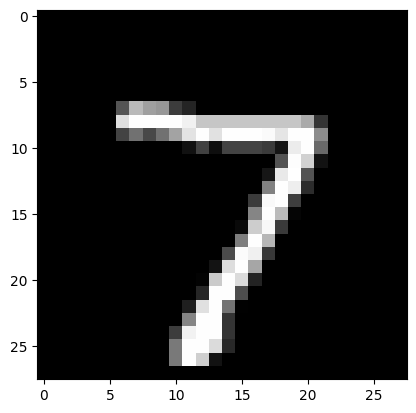

In [19]:
plt.imshow(image, cmap = 'gray')

Por padrão as imagens no pytorch tem o seguinte padrão:

(batch_number, channel_numbers, height, width)

como a imagem acima (tinha shape (1, 28, 28)), e agora tem shape (28, 28), precisamos converter o seu shape para (1, 1, 28, 28) pois retirando a imagem do batch, é como se ela pertencesse a um batch de uma única imagem, ela tem apenas um canal (escala cinza), e tem dimensões 28 x 28

In [20]:
image = image.view(1, 1, 28, 28)
image.shape

torch.Size([1, 1, 28, 28])

Faz uma previsão

In [21]:
net.eval()
image = image.to(device)
net.eval()

previsao = net.forward(image)
previsao = F.softmax(previsao, dim = 1)
previsao

tensor([[2.3866e-06, 1.2985e-05, 3.6936e-05, 1.7845e-04, 1.8998e-08, 1.9258e-06,
         8.6201e-10, 9.9976e-01, 7.3474e-07, 8.0148e-06]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

Passa a previsao para a cpu para converte-la para o formato numpy array:
OBS: Poderia tambem fazer:

 _, top_class = previsao.topk(k=1, dim=1)
 
 resultado = int(top_class.item())

In [22]:
previsao = previsao.cpu().detach().numpy()
previsao

array([[2.3866437e-06, 1.2984603e-05, 3.6936039e-05, 1.7845465e-04,
        1.8997573e-08, 1.9258448e-06, 8.6200785e-10, 9.9975866e-01,
        7.3474092e-07, 8.0148093e-06]], dtype=float32)

Retorna o indice de maior valor

In [23]:
resultado = int(np.argmax(previsao))
resultado

7